In [1]:
"""
Moment-SoS W2 distance map — adapted for create_data() output
==============================================================

Data structure (from create_data):
  • stock1 / stock2 : dict  key = str(l)+str(c), value = 1-D np.ndarray
  • Every sample is normalised to [0, 1]  (divided by its own max)
    → support is always [0, 1]
  • Columns 30-34 of stock2 carry an additive bias (niveauBiais),
    re-normalised afterward → still in [0, 1]

Three computation paths (all return the same shape):
  1. wasserstein_moment_map()               raw stock dicts  → W2 map  (SDP or empirical)
  2. wasserstein_moment_map_from_moments()  pre-built moment matrices → W2 map
  3. wasserstein_empirical_map()            exact empirical W2 (no SDP, fastest)

Math reference: Mula & Nouy 2022, Sections 4.1 & 6
  W2²(µ,ν) = min_{y ∈ Π_mom([0,1]²)}  y(2,0) - 2·y(1,1) + y(0,2)
  subject to marginal + Putinar SoS constraints (Theorem 3.4)

Dependencies
------------
  numpy   — always required
  cvxpy   — required for SDP path  (pip install cvxpy)
  tqdm    — optional progress bar   (pip install tqdm)
"""

from matplotlib import cm
from matplotlib.colors import ListedColormap
import numpy as np
import warnings
import matplotlib.pyplot as plt

# ── optional imports ────────────────────────────────────────────────────────
try:
    import cvxpy as cp
    _CVXPY = True
except ImportError:
    _CVXPY = False
    warnings.warn(
        "cvxpy not found – SDP path disabled. "
        "Install it with:  pip install cvxpy\n"
        "Falling back to exact empirical W2 for all calls.",
        stacklevel=2,
    )

try:
    from tqdm import tqdm as _tqdm
    def _progress(it, **kw): return _tqdm(it, **kw)
except ImportError:
    def _progress(it, **kw): return it


# ═══════════════════════════════════════════════════════════════════════════
# 0. Data generation  (faithful to original create_data, fully annotated)
# ═══════════════════════════════════════════════════════════════════════════

def create_data(size_carte, niveauBiais):
    """
    Generate reference (stock1) and biased (stock2) sample dictionaries.

    Key design choices that matter for the W2 computation:
      • Each pixel sample is divided by its own max  → values in [0, 1]
        This fixes the support to [0, 1] and lets the SDP use a = 0, b = 1.
      • Three concentric zones have increasingly large sample counts so that
        the inner pixels have much tighter moment estimates.
      • Columns 30-34 of stock2 receive an additive bias then are
        re-normalised, shifting their distribution rightward.

    Returns
    -------
    carte1, carte2           : (size_carte, size_carte) mean maps
    mat_nombres_ech1/ech2    : (size_carte, size_carte) sample-count maps
    var_carte1, var_carte2   : (size_carte, size_carte) std-dev maps
    stock1, stock2           : dict {str(l)+str(c): np.ndarray in [0,1]}
    """
    # Underlying distribution parameters (one per pixel)
    mat_variance = np.abs(np.random.normal(0, 1, size=(size_carte, size_carte)))
    mat_moyenne  = np.abs(np.random.normal(0, 1, size=(size_carte, size_carte)))

    # Sample counts: outer ring ~100, middle ring ~1 000–5 000, core ~10 000
    mat_nombres_ech1 = np.random.randint(100, 120, (size_carte, size_carte))
    mat_nombres_ech2 = mat_nombres_ech1 + np.random.randint(-10, 10,
                                                             (size_carte, size_carte))

    taille = mat_nombres_ech1[9:55, 9:55].shape
    mat_nombres_ech1[9:55, 9:55]  = np.random.randint(1000, 1200, taille)
    mat_nombres_ech2[9:55, 9:55]  = (mat_nombres_ech1[9:55, 9:55]
                                      + np.random.randint(-50, 50, taille))

    taille = mat_nombres_ech1[18:46, 18:46].shape
    mat_nombres_ech1[18:46, 18:46] = np.random.randint(5000, 5500, taille)
    mat_nombres_ech2[18:46, 18:46] = (mat_nombres_ech1[18:46, 18:46]
                                       + np.random.randint(-200, 200, taille))

    taille = mat_nombres_ech1[27:37, 27:37].shape
    mat_nombres_ech1[27:37, 27:37] = np.random.randint(10000, 11000, taille)
    mat_nombres_ech2[27:37, 27:37] = (mat_nombres_ech1[27:37, 27:37]
                                       + np.random.randint(-1000, 1000, taille))

    # Per-pixel sample generation + normalisation to [0, 1]
    stock1    = {}
    stock2    = {}
    carte1    = np.zeros((size_carte, size_carte))
    carte2    = np.zeros((size_carte, size_carte))
    var_carte1 = np.zeros((size_carte, size_carte))
    var_carte2 = np.zeros((size_carte, size_carte))

    for l in range(size_carte):
        for c in range(size_carte):
            key = str(l) + str(c)

            s1 = np.abs(np.random.normal(mat_variance[l, c],
                                          mat_moyenne[l, c],
                                          mat_nombres_ech1[l, c]))
            s2 = np.abs(np.random.normal(mat_variance[l, c],
                                          mat_moyenne[l, c],
                                          mat_nombres_ech2[l, c]))

            # Normalise to [0, 1] — critical for the SDP (support = [0, 1])
            stock1[key] = s1 / s1.max()
            stock2[key] = s2 / s2.max()

            carte1[l, c]     = np.mean(stock1[key])
            var_carte1[l, c] = np.std(stock1[key])
            carte2[l, c]     = np.mean(stock2[key])
            var_carte2[l, c] = np.std(stock2[key])

    # Add bias on columns 30-34 then re-normalise (keeps support in [0, 1])
    for l in range(size_carte):
        for c in range(30, 35):
            key  = str(l) + str(c)
            s2b  = stock2[key] + niveauBiais
            s2b  = s2b / s2b.max()          # re-normalise → still in [0, 1]
            stock2[key]      = s2b
            carte2[l, c]     = np.mean(s2b)
            var_carte2[l, c] = np.std(s2b)

    return (carte1, carte2,
            mat_nombres_ech1, mat_nombres_ech2,
            var_carte1, var_carte2,
            stock1, stock2)


# ═══════════════════════════════════════════════════════════════════════════
# 1. Moment helpers
# ═══════════════════════════════════════════════════════════════════════════

def calcul_100_moments(ech):
    """
    Return moments [m₁, m₂, …, m₁₀₀] of a 1-D empirical sample.
    m_k = E[X^k].  Identical convention to the original codebase.
    """
    ech    = np.asarray(ech, dtype=np.float64)
    moments = np.zeros(101, dtype=np.float64)
    power  = np.ones_like(ech)
    for i in range(101):
        moments[i] = np.mean(power)
        power *= ech
    return list(moments[1:])   # m₁ … m₁₀₀


def _moments_dict(ech, max_order):
    """
    Internal helper: return {k: E[X^k]} for k = 0 … max_order.
    k=0 always equals 1.0 (probability measure).
    Samples must lie in [0, 1] — guaranteed by create_data.
    """
    ech = np.asarray(ech, dtype=np.float64)
    m, pw = {}, np.ones_like(ech)
    for k in range(max_order + 1):
        m[k] = float(np.mean(pw))
        pw  *= ech
    return m


def create_matrice_moments(matrices_simulees, matrice_size=64):
    """
    Build the 100-moment matrix from a stock dict or 2-D list.
    Unchanged interface from the original codebase.
    """
    matrice_moments = [[[] for _ in range(matrice_size)]
                       for _ in range(matrice_size)]
    for i in range(matrice_size):
        for j in range(matrice_size):
            if isinstance(matrices_simulees, dict):
                ech = matrices_simulees[str(i) + str(j)]
            else:
                ech = matrices_simulees[i][j]
            matrice_moments[i][j] = calcul_100_moments(ech)
    return matrice_moments


# ═══════════════════════════════════════════════════════════════════════════
# 2. Exact empirical W2² for 1-D  (quantile formula, reference / fallback)
# ═══════════════════════════════════════════════════════════════════════════

def _w2sq_empirical(s1, s2):
    """
    Exact W2² for two 1-D equal-weight empirical distributions on [0, 1].
    Uses the quantile (inverse-CDF) representation:
        W2²(µ,ν) = ∫₀¹ (F_µ⁻¹(t) − F_ν⁻¹(t))² dt
    Handles unequal sample sizes via quantile interpolation.
    """
    u = np.sort(np.asarray(s1, dtype=np.float64))
    v = np.sort(np.asarray(s2, dtype=np.float64))
    if len(u) == len(v):
        return float(np.mean((u - v) ** 2))
    n_grid = max(len(u), len(v))
    t      = np.linspace(0.0, 1.0, n_grid + 1)[:-1] + 0.5 / n_grid
    return float(np.mean((np.quantile(u, t) - np.quantile(v, t)) ** 2))


# ═══════════════════════════════════════════════════════════════════════════
# 3. Moment-SoS SDP for W2²  (Sections 4.1 & 6, Mula & Nouy 2022)
#    Support is always [0, 1] × [0, 1] — guaranteed by normalisation.
# ═══════════════════════════════════════════════════════════════════════════

def _w2sq_sdp(mu, nu, r=2, verbose=False):
    """
    Solve the order-r SoS-moment SDP to approximate W2²(µ, ν).

    Decision variables
    ------------------
    y[(α, β)]  for α + β ≤ 2r  — truncated moment sequence of the
    transport plan π on [0,1]².

    Objective  (p = 2 even, Section 4.1 of the paper):
        min  y(2,0) − 2·y(1,1) + y(0,2)     ← = E_π[(x−t)²]

    Marginal constraints  (eq. 6 of the paper):
        y(k, 0) = m_k(µ),   y(0, k) = m_k(ν),   k = 0 … 2r

    Putinar SoS conditions for [0,1]²  (Theorem 3.4 + Remark 3.5):
        M_r(y)              ⪰ 0   g₀ = 1
        M_{r-1}((1−x)·y)   ⪰ 0   g₁ = 1 − x ≥ 0  (x ≤ 1)
        M_{r-1}(x·y)        ⪰ 0   g₂ = x ≥ 0       (x ≥ 0)
        M_{r-1}((1−t)·y)   ⪰ 0   g₃ = 1 − t ≥ 0  (t ≤ 1)
        M_{r-1}(t·y)        ⪰ 0   g₄ = t ≥ 0       (t ≥ 0)

    Parameters
    ----------
    mu, nu  : dict {k: float}   marginal moment dicts  (k = 0 … 2r)
    r       : int               relaxation order  (r ≥ 1)
    verbose : bool

    Returns
    -------
    float   W2²(µ,ν) ≥ 0,  or np.nan on solver failure
    """
    # ── Moment variables: y[(α,β)] for α+β ≤ 2r ──────────────────────────
    keys = [(a, b)
            for a in range(2 * r + 1)
            for b in range(2 * r + 1)
            if a + b <= 2 * r]
    y = {k: cp.Variable(name=f"y_{k[0]}_{k[1]}") for k in keys}

    constraints = []

    # ── Marginal constraints ───────────────────────────────────────────────
    for k in range(2 * r + 1):
        if (k, 0) in y:
            constraints.append(y[(k, 0)] == mu.get(k, 0.0))
        if (0, k) in y:
            constraints.append(y[(0, k)] == nu.get(k, 0.0))

    # ── Localising matrix  M_{r_loc}(g · y) ⪰ 0 ─────────────────────────
    # g_terms: [(scalar_coeff, (deg_in_x, deg_in_t)), …]
    def psd_constraint(r_loc, g_terms):
        idx = [(a, b)
               for a in range(r_loc + 1)
               for b in range(r_loc + 1)
               if a + b <= r_loc]
        rows = []
        for (a1, b1) in idx:
            row = []
            for (a2, b2) in idx:
                entry = sum(
                    gc * (y[(a1 + a2 + da, b1 + b2 + db)]
                          if (a1 + a2 + da, b1 + b2 + db) in y
                          else 0.0)
                    for gc, (da, db) in g_terms
                )
                row.append(cp.reshape(entry, (1, 1)))
            rows.append(row)
        return cp.bmat(rows) >> 0

    # g₀ = 1  →  M_r(y) ⪰ 0
    constraints.append(psd_constraint(r, [(1.0, (0, 0))]))

    if r >= 1:
        r1 = r - 1
        # g₁ = 1 − x  (upper bound on first variable)
        constraints.append(psd_constraint(r1, [(1.0, (0, 0)), (-1.0, (1, 0))]))
        # g₂ = x       (lower bound on first variable)
        constraints.append(psd_constraint(r1, [(1.0, (1, 0))]))
        # g₃ = 1 − t  (upper bound on second variable)
        constraints.append(psd_constraint(r1, [(1.0, (0, 0)), (-1.0, (0, 1))]))
        # g₄ = t       (lower bound on second variable)
        constraints.append(psd_constraint(r1, [(1.0, (0, 1))]))

    # ── Objective ─────────────────────────────────────────────────────────
    objective = y[(2, 0)] - 2.0 * y[(1, 1)] + y[(0, 2)]
    problem   = cp.Problem(cp.Minimize(objective), constraints)

    # Try solvers in order of preference; fall back gracefully
    for solver in [cp.SCS, cp.CLARABEL, None]:
        try:
            kw = dict(verbose=verbose)
            if solver == cp.SCS:
                kw.update(eps=1e-9, max_iters=20000)
            problem.solve(solver=solver, **kw) if solver else problem.solve(**kw)
            if problem.value is not None and np.isfinite(problem.value):
                return max(float(problem.value), 0.0)
        except Exception:
            continue

    return np.nan


# ═══════════════════════════════════════════════════════════════════════════
# 4. Single-pixel W2
# ═══════════════════════════════════════════════════════════════════════════

def _w2_one_pixel(s_ref, s_brut, r=2, use_sdp=True):
    """
    W2 distance for one pixel pair.

    Parameters
    ----------
    s_ref, s_brut : 1-D array-like  Values must be in [0, 1] — as produced
                    by create_data (normalised by max).
    r             : int   SDP relaxation order (1 or 2 is enough per Fig. 2b)
    use_sdp       : bool  True → Moment-SoS SDP; False → exact empirical

    Returns
    -------
    float  W2(µ, ν) ≥ 0
    """
    sr = np.clip(np.asarray(s_ref,  dtype=np.float64), 0.0, 1.0)
    sb = np.clip(np.asarray(s_brut, dtype=np.float64), 0.0, 1.0)

    if not use_sdp or not _CVXPY:
        return np.sqrt(max(_w2sq_empirical(sr, sb), 0.0))

    mu   = _moments_dict(sr, 2 * r)
    nu   = _moments_dict(sb, 2 * r)
    w2sq = _w2sq_sdp(mu, nu, r=r)

    if np.isnan(w2sq):          # solver failed → safe empirical fallback
        w2sq = _w2sq_empirical(sr, sb)

    return np.sqrt(max(w2sq, 0.0))


# ═══════════════════════════════════════════════════════════════════════════
# 5.  W2 map from stock dicts  — drop-in replacement for wasserstein()
# ═══════════════════════════════════════════════════════════════════════════

def wasserstein_moment_map(stock_ref, stock_brut,
                           matrice_size=64, r=2, use_sdp=True):
    """
    Pixel-wise W2 distance map using the Moment-SoS approach.

    Accepts the exact output of create_data() and matches the interface of
    the original wasserstein() function.

    Parameters
    ----------
    stock_ref, stock_brut : dict {str(l)+str(c): np.ndarray in [0,1]}
                            or 2-D list of 1-D arrays
                            Direct output of create_data() → no pre-processing needed.
    matrice_size : int    grid side length  (default 64)
    r            : int    SDP relaxation order 1–5
                          r=1 is typically enough (see Fig. 2b of the paper).
                          Higher r = more accurate but exponentially slower.
    use_sdp      : bool   True  → Moment-SoS SDP (requires cvxpy, more principled)
                          False → exact empirical W2 (faster, no cvxpy required)

    Returns
    -------
    w2_map : np.ndarray  shape (matrice_size, matrice_size)
             w2_map[l, c] = W2( stock_ref pixel (l,c), stock_brut pixel (l,c) )
    """
    method = f"Moment-SoS r={r}" if (use_sdp and _CVXPY) else "empirical W2"
    w2_map = np.zeros((matrice_size, matrice_size))

    for l in _progress(range(matrice_size), desc=f"W2 map ({method})"):
        for c in range(matrice_size):
            if isinstance(stock_ref, dict):
                key    = str(l) + str(c)
                s_ref  = stock_ref[key]
                s_brut = stock_brut[key]
            else:
                s_ref  = stock_ref[l][c]
                s_brut = stock_brut[l][c]

            w2_map[l, c] = _w2_one_pixel(s_ref, s_brut, r=r, use_sdp=use_sdp)

    return w2_map


# ═══════════════════════════════════════════════════════════════════════════
# 6.  W2 map from pre-computed moment matrices
#     Uses output of create_matrice_moments() — avoids keeping raw samples
# ═══════════════════════════════════════════════════════════════════════════

def wasserstein_moment_map_from_moments(matrice_moments_ref,
                                        matrice_moments_brut,
                                        matrice_size=64, r=2, use_sdp=True):
    """
    Pixel-wise W2 map from pre-computed 100-moment matrices.

    Parameters
    ----------
    matrice_moments_ref / _brut : 2-D list
        matrice_moments_ref[l][c] = [m₁, …, m₁₀₀]  (output of
        create_matrice_moments).  The zeroth moment (=1) is added
        automatically.  Support is [0, 1] (guaranteed by create_data).
    matrice_size : int
    r            : int   relaxation order  (2r ≤ 100,  i.e. r ≤ 50)
    use_sdp      : bool  True → SDP;  False → Gaussian lower bound from
                         first two moments: W2² ≈ (μ₁−μ₂)² + (σ₁−σ₂)²

    Returns
    -------
    w2_map : np.ndarray  shape (matrice_size, matrice_size)
    """
    if r > 50:
        raise ValueError(f"r={r} requires moments beyond order 100 (max r=50).")

    method = f"Moment-SoS r={r}" if (use_sdp and _CVXPY) else "moment approx"
    w2_map = np.zeros((matrice_size, matrice_size))

    for l in _progress(range(matrice_size), desc=f"W2 from moments ({method})"):
        for c in range(matrice_size):
            # moment lists: index 0 = m₁, index k-1 = m_k
            m_ref  = matrice_moments_ref[l][c]
            m_brut = matrice_moments_brut[l][c]

            mu = {0: 1.0, **{k: float(m_ref[k - 1])  for k in range(1, 2*r+1)}}
            nu = {0: 1.0, **{k: float(m_brut[k - 1]) for k in range(1, 2*r+1)}}

            if use_sdp and _CVXPY:
                w2sq = _w2sq_sdp(mu, nu, r=r)
                if np.isnan(w2sq):
                    w2sq = 0.0
            else:
                # Closed-form lower bound (exact for Gaussian distributions):
                #   W2²(µ,ν) ≥ (mean_µ − mean_ν)² + (std_µ − std_ν)²
                var_r = max(mu[2] - mu[1] ** 2, 0.0)
                var_b = max(nu[2] - nu[1] ** 2, 0.0)
                w2sq  = (mu[1] - nu[1]) ** 2 + (np.sqrt(var_r) - np.sqrt(var_b)) ** 2

            w2_map[l, c] = np.sqrt(max(w2sq, 0.0))

    return w2_map


# ═══════════════════════════════════════════════════════════════════════════
# 7.  Convenience alias: exact empirical W2 map  (no SDP, fastest)
# ═══════════════════════════════════════════════════════════════════════════

def wasserstein_empirical_map(stock_ref, stock_brut, matrice_size=64):
    """
    Exact empirical W2 map (quantile formula, no cvxpy required).
    Same interface and output as wasserstein_moment_map(..., use_sdp=False).
    Use as a fast baseline or when cvxpy is unavailable.
    """
    return wasserstein_moment_map(stock_ref, stock_brut,
                                  matrice_size=matrice_size,
                                  r=1, use_sdp=False)





top = cm.get_cmap('viridis', 64)

bottom = cm.get_cmap('plasma', 960)

newcolors = np.vstack((top(np.linspace(0, 1, 64)),

                       bottom(np.linspace(1, 0, 960))))

newcmp = ListedColormap(newcolors, name='MonteCarlo')

def affichage_matrices(matrice_reference, matrice_bruitee, matrice_metrique, metrique_name):
    #plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.title("Matrice de référence")
    plt.imshow(matrice_reference, cmap=newcmp)
    #plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title("Matrice bruitée")
    plt.imshow(matrice_bruitee, cmap=newcmp)
    #plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title(f"Métrique : {metrique_name}")
    plt.imshow(matrice_metrique, cmap=newcmp)
    #plt.colorbar()

    plt.tight_layout()
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# 8.  Self-test
# ═══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    np.random.seed(42)
    SIZE = 64
    BIAS = 0.05

    print(f"Generating {SIZE}×{SIZE} data  (niveauBiais={BIAS}) …")
    (carte1, carte2,
     ech1, ech2,
     var1, var2,
     stock1, stock2) = create_data(SIZE, BIAS)

    # ── Empirical W2 map (exact, no SDP needed) ───────────────────────────
    print("\n── Empirical W2 map ──")
    W_emp = wasserstein_empirical_map(stock1, stock2, matrice_size=SIZE)
    col_bias   = W_emp[:, 30:35].mean()
    col_unbias = np.delete(W_emp, np.arange(30, 35), axis=1).mean()
    print(f"  Mean W2  biased   cols 30–34 : {col_bias:.4f}")
    print(f"  Mean W2  unbiased cols       : {col_unbias:.4f}")
    print(f"  Ratio bias / unbiased        : {col_bias / col_unbias:.2f}x")

    # ── Moment-SoS map (SDP, r=1) ─────────────────────────────────────────
    if _CVXPY:
        print("\n── Moment-SoS W2 map  r=1 ──")
        W_sos = wasserstein_moment_map(stock1, stock2,
                                       matrice_size=SIZE, r=1, use_sdp=True)
        diff = np.abs(W_emp - W_sos)
        print(f"  Max  |empirical − SoS| : {diff.max():.2e}")
        print(f"  Mean |empirical − SoS| : {diff.mean():.2e}")
    else:
        print("\ncvxpy not installed — install with:  pip install cvxpy")

    # ── Pre-computed moments path ─────────────────────────────────────────
    print("\n── W2 from pre-computed moment matrices (r=2) ──")
    mm1 = create_matrice_moments(stock1, matrice_size=SIZE)
    mm2 = create_matrice_moments(stock2, matrice_size=SIZE)
    W_mom = wasserstein_moment_map_from_moments(mm1, mm2,
                                                matrice_size=SIZE,
                                                r=2, use_sdp=_CVXPY)
    diff2 = np.abs(W_emp - W_mom)
    print(f"  Max  |empirical − moments path| : {diff2.max():.2e}")
    print(f"  Mean |empirical − moments path| : {diff2.mean():.2e}")




/tmp/ipykernel_70595/1255055346.py:478: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  top = cm.get_cmap('viridis', 64)
/tmp/ipykernel_70595/1255055346.py:480: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bottom = cm.get_cmap('plasma', 960)


Generating 64×64 data  (niveauBiais=0.05) …

── Empirical W2 map ──


W2 map (empirical W2): 100%|██████████| 64/64 [00:52<00:00,  1.22it/s]


  Mean W2  biased   cols 30–34 : 0.0460
  Mean W2  unbiased cols       : 0.0427
  Ratio bias / unbiased        : 1.08x

── Moment-SoS W2 map  r=1 ──


W2 map (Moment-SoS r=1):   0%|          | 0/64 [00:00<?, ?it/s]/home/ensai/.local/lib/python3.10/site-packages/cvxpy/atoms/affine/reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)
/home/ensai/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
W2 map (Moment-SoS r=1): 100%|██████████| 64/64 [00:50<00:00,  1.28it/s]


  Max  |empirical − SoS| : 4.88e-02
  Mean |empirical − SoS| : 4.85e-03

── W2 from pre-computed moment matrices (r=2) ──


W2 from moments (Moment-SoS r=2): 100%|██████████| 64/64 [15:59<00:00, 14.99s/it]

  Max  |empirical − moments path| : 2.80e-02
  Mean |empirical − moments path| : 3.51e-03


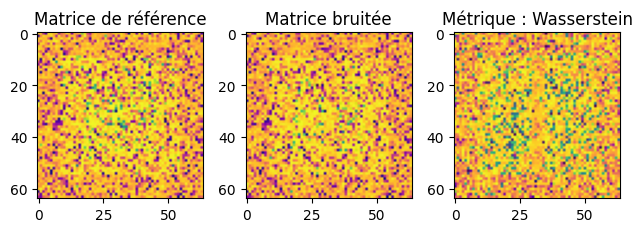

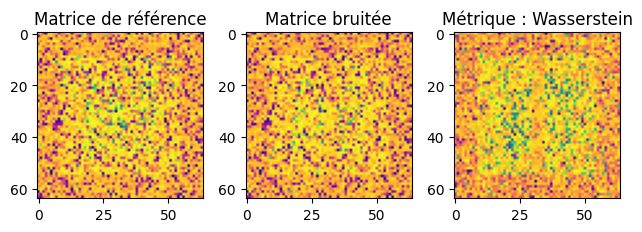

In [2]:
affichage_matrices(carte1, carte2, W_mom, "Wasserstein")
affichage_matrices(carte1, carte2, W_emp, "Wasserstein")

